In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import requests
import tiktoken
import pandas as pd

In [13]:
batch_size = 4
context_length = 16 # seq_length
d_model = 512
num_heads = 8
device = 'cuda' if torch.cuda.is_available() else 'cpu'

TORCH_SEED = 42
torch.manual_seed(TORCH_SEED)


In [8]:
# 准备数据集
with open('data/scifiv2.txt', 'r', encoding="utf-8") as file:
    text = file.read()

In [9]:
# 使用 tiktoken 分词器
enc = tiktoken.get_encoding("cl100k_base")
tokenized_text = enc.encode(text)

total_texts = len(text)
total_tokens = len(tokenized_text)
vocab_size = len(set(tokenized_text))
max_token_value = max(tokenized_text)

print(f"Total texts: {total_texts}")
print(f"Total tokens: {total_tokens}")
print(f"Vocab size: {vocab_size}")
print(f"Vocab size: {max_token_value}")

Total texts: 36094592
Total tokens: 45095389
Vocab size: 5129
Vocab size: 100207


In [10]:
# 使用 integer mapping 分词器
characters = sorted(list(set(text)))
i2s = {i:ch for i,ch in enumerate(characters)}
s2i = {ch:i for i,ch in enumerate(characters)}

def encode(texts):
    return [s2i[ch] for ch in texts]

def decode(integers):
    return ''.join([i2s[i] for i in integers])

tokenized_text = encode(text)
max_token_value = max(tokenized_text)

print(f"Total tokens: {len(tokenized_text)}")
print(f"Vocab size: {max_token_value}")
print(f"Vocab size: {max_token_value}")

Total tokens: 36094592
Vocab size: 5884
Vocab size: 5884


In [11]:
embedding = nn.Embedding(16,512)
embedding.weight.shape

torch.Size([16, 512])

In [14]:
tokenized_text = torch.tensor(tokenized_text, dtype=torch.long, device=device)

split_idx = int(len(tokenized_text) * 0.9)
train_data = tokenized_text[:split_idx]
val_data = tokenized_text[split_idx:]

In [15]:
# 模拟 x_batch, y_batch 数据集

idxs = torch.randint(low=0, high=len(train_data) - context_length, size=(batch_size,))
x_batch = torch.stack([train_data[idx:idx + context_length] for idx in idxs])
y_batch = torch.stack([train_data[idx + 1:idx + context_length + 1] for idx in idxs])
x_batch.shape

torch.Size([4, 16])

In [16]:
token_embedding_lookup_table = nn.Embedding(max_token_value, d_model)
x = token_embedding_lookup_table(x_batch)
y = token_embedding_lookup_table(y_batch)
# x.shape, y.shape

tb_weights_before = token_embedding_lookup_table.get_parameter(target='weight')

In [17]:
pd.DataFrame(x[0].detach().cpu().numpy())
xx = pd.DataFrame(x[0].detach().cpu().numpy())
pd.set_option('display.expand_frame_repr', False)
print("Our batches:\n", pd.DataFrame(xx))

Our batches:
          0         1         2         3         4         5         6         7         8         9    ...       502       503       504       505       506       507       508       509       510       511
0  -1.626015  0.401002 -0.164860  0.648824  1.265589 -0.248382 -0.171047  1.012511 -0.668548 -0.070836  ... -1.027264 -0.704909  1.107473  0.585830 -0.976870  0.094349 -2.062318  0.813820 -0.678593  0.462835
1  -0.700816  0.238029 -1.210699  0.632100 -1.634489  0.250462 -2.942685 -0.054395  2.034574 -1.133902  ... -0.060709 -0.435358  1.397368  0.316986  0.444319  0.735316  1.163270 -0.444529 -1.050224 -0.030774
2   1.040755  0.077527  0.354732 -0.721198 -1.183982 -0.249218 -0.572319 -0.070753  0.903129 -1.029639  ...  0.842205  1.215236  1.218327  0.323726 -1.170790 -0.288027  0.663077 -1.248103 -2.143064 -0.204080
3  -2.101354  0.789039  0.925327  1.842876  1.072280 -0.701199  0.315318  0.123764 -0.286819 -0.153549  ...  0.088701  0.067933 -0.103593 -1.005661  0.631

In [18]:
# Positional encoding 位置编码
import math
position_encoding_lookup_table = torch.zeros(context_length, d_model)
position = torch.arange(0, context_length, dtype=torch.float).unsqueeze(1)

div_term = torch.exp(-math.log(10000.0) * torch.arange(0, d_model, 2, dtype=torch.float) / d_model)
position_encoding_lookup_table[:, 0::2] = torch.sin(position * div_term)
position_encoding_lookup_table[:, 1::2] = torch.cos(position * div_term)
position_encoding_lookup_table = position_encoding_lookup_table.unsqueeze(0).expand(batch_size, -1, -1)
position_encoding_lookup_table.shape
# pd.DataFrame(position_encoding_lookup_table[0].detach().cpu().numpy())

torch.Size([4, 16, 512])

In [20]:
x = x + position_encoding_lookup_table
pd.DataFrame(x[0].detach().cpu().numpy())

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
0,-1.626015,2.401002,-0.164860,2.648824,1.265589,1.751618,-0.171047,3.012511,-0.668548,1.929164,...,-1.027264,1.295091,1.107473,2.585830,-0.976870,2.094349,-2.062318,2.813819,-0.678593,2.462835
1,0.982126,1.318634,0.433013,1.771490,-0.030566,1.445213,-1.378911,1.192445,3.558015,0.161910,...,-0.060469,1.564642,1.397599,2.316986,0.444542,2.735317,1.163485,1.555471,-1.050016,1.969226
2,2.859350,-0.754767,2.227561,-1.422988,0.732307,-0.821789,1.377457,-0.516143,2.877222,-1.350510,...,0.842684,3.215236,1.218789,2.323725,-1.170344,1.711973,0.663507,0.751897,-2.142650,1.795920
3,-1.819114,-1.190946,1.415498,-0.096127,1.757844,-2.580029,1.182603,-1.678406,0.747793,-1.865150,...,0.089420,2.067933,-0.102900,0.994339,0.632060,1.298144,-0.437030,1.450964,-1.581008,1.696642
4,-2.029359,-1.655152,-1.611536,-1.465882,-1.872520,-1.044577,-2.385165,-2.273542,0.155306,-0.243318,...,-0.127453,2.585664,-1.301211,3.241623,-1.186927,2.313229,1.227320,2.084374,0.104739,2.942133
5,-0.407677,0.779629,-2.712911,-0.731390,-2.839246,-1.760256,-2.668148,-0.553128,-3.646096,-0.653314,...,-0.409160,2.468094,0.142914,3.108468,0.555537,3.581750,-0.557450,2.663694,-1.701422,3.669645
6,0.128441,2.703930,-2.061316,-1.346596,-1.825834,1.042996,-0.317492,0.182480,-1.219423,3.584520,...,-0.407881,1.927809,-0.753223,1.966588,-0.826313,1.647583,-1.236446,1.653852,0.303217,1.149421
7,2.001245,2.291394,-0.206089,-1.322690,-0.080227,1.459952,1.246753,0.934663,0.112159,4.606108,...,-0.407641,1.927809,-0.752992,1.966588,-0.826090,1.647583,-1.236232,1.653852,0.303424,1.149421
8,2.665989,0.492590,0.870472,-2.833801,1.296939,0.309121,2.810056,0.180526,1.753064,4.253707,...,-0.407402,1.927809,-0.752761,1.966588,-0.825867,1.647583,-1.236017,1.653852,0.303631,1.149421
9,1.511509,-1.038671,0.241867,-4.579452,1.196701,-1.482792,3.195001,-1.511945,2.547784,2.775475,...,-0.407163,1.927809,-0.752530,1.966588,-0.825644,1.647582,-1.235802,1.653852,0.303839,1.149420


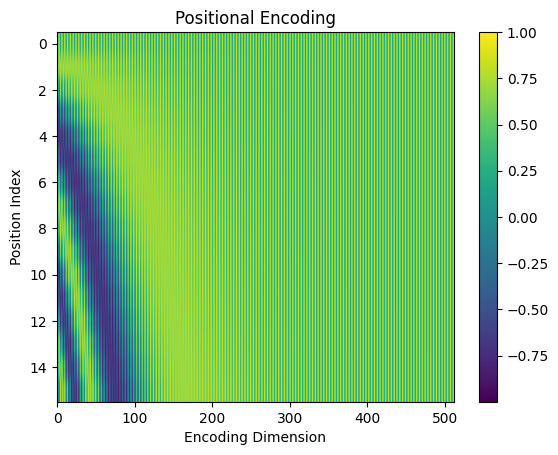

In [21]:
# 另外一种方法
import numpy as np
def positionalEncoding(length, d, n=10000):
    P = np.zeros((length, d))
    for j in range(length):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[j, 2*i] = np.sin(j/denominator)
            P[j, 2*i+1] = np.cos(j/denominator)
    return P
# Illustration Purpose Only
import matplotlib.pyplot as plt
def visualize_pe(pe):
    plt.imshow(pe, aspect="auto")
    plt.title("Positional Encoding")
    plt.xlabel("Encoding Dimension")
    plt.ylabel("Position Index")
    plt.colorbar()
    plt.show()

visualize_pe(positionalEncoding(context_length, d_model))

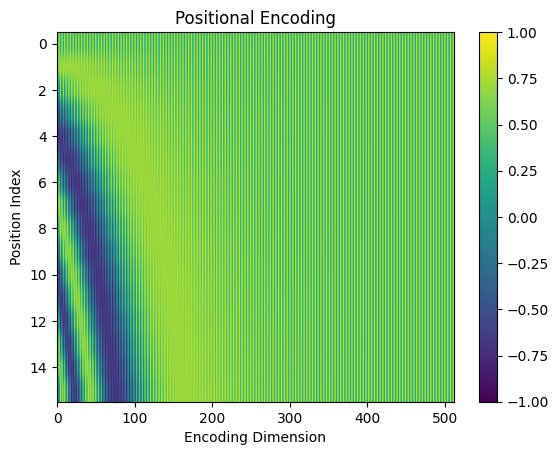

In [22]:
# Illustration Purpose Only
import matplotlib.pyplot as plt
def visualize_pe(pe):
    plt.imshow(pe, aspect="auto")
    plt.title("Positional Encoding")
    plt.xlabel("Encoding Dimension")
    plt.ylabel("Position Index")
    plt.colorbar()
    plt.show()

visualize_pe(position_encoding_lookup_table[0].cpu().numpy())

In [23]:
# Multi-head attention 多头注意力机制（注意：这里的实现是跟论文中的实现不一样的。论文实际上是为每个头做了Wq、Wk、Wv。我们在手写第二期时使用论文中方法。）
Wq = nn.Linear(d_model, d_model)
Wk = nn.Linear(d_model, d_model)
Wv = nn.Linear(d_model, d_model)

Q = Wq(x)
K = Wk(x)
V = Wv(x)

Q = Q.reshape(batch_size, context_length, num_heads, -1).permute(0, 2, 1, 3)
K = K.reshape(batch_size, context_length, num_heads, -1).permute(0, 2, 1, 3)
V = V.reshape(batch_size, context_length, num_heads, -1).permute(0, 2, 1, 3)
Q.shape, K.transpose(-2, -1).shape

(torch.Size([4, 8, 16, 64]), torch.Size([4, 8, 64, 16]))

In [24]:
# Q @ K^T
attn = Q @ K.transpose(-2, -1)
attn.shape

torch.Size([4, 8, 16, 16])

In [25]:
pd.DataFrame(attn[0][0].detach().cpu().numpy())


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,5.115134,-1.811998,6.186625,5.507452,10.689178,10.675184,6.470711,4.602254,1.781723,-0.983785,-2.391095,0.565717,-10.738490,4.685486,1.392100,-8.154077
1,2.213768,0.130480,4.532764,1.947003,11.919080,2.812999,4.160251,2.376070,0.460374,-1.041421,-7.724656,-2.380972,-10.174978,-0.864133,3.020031,-8.053981
2,-3.557833,-3.970106,-4.192739,-3.281875,-2.914712,-10.645594,0.614152,1.286739,0.918729,-0.565652,-6.367425,-5.430281,-14.150184,0.577536,-5.513661,-7.668314
3,-4.254281,-5.417060,-3.447814,2.163520,1.789329,-9.724937,1.330068,1.890767,2.340777,2.212212,-5.430970,-1.979352,-11.597622,-2.422389,-9.944204,-13.013570
4,0.984252,0.952257,-3.361711,13.043512,19.676044,1.349634,9.564645,10.221822,11.198182,11.720549,4.367461,5.214545,-6.258722,4.484551,-0.065541,-5.231594
5,2.314086,5.428745,1.615728,9.749957,17.045317,1.563150,8.862110,9.507570,10.278033,10.403795,7.092345,9.679073,-8.147545,2.337369,2.888069,-5.340866
6,-2.306162,-3.508592,-1.409982,4.651103,11.061450,0.862160,3.524391,3.054702,2.455843,1.538326,-5.821309,-5.164509,-12.449635,-6.880449,-5.513148,-17.734280
7,-2.410145,-4.465588,-1.325222,2.762902,10.525708,1.592165,2.715651,1.995051,1.084644,-0.025753,-7.681477,-6.410392,-12.832714,-6.463233,-7.150307,-18.769175
8,-3.370090,-5.621382,-2.654539,0.426290,9.582800,0.200339,2.545057,1.846592,0.858040,-0.278663,-8.974869,-7.225794,-12.737925,-5.082205,-7.944352,-18.588812
9,-3.795842,-5.242035,-4.318376,-0.919395,9.462036,-1.854691,3.559589,3.010534,2.078284,1.009979,-9.172239,-7.386269,-12.145211,-3.342485,-7.227208,-16.948782


In [26]:
attn = attn / math.sqrt(d_model // num_heads)
pd.DataFrame(attn[0][0].detach().cpu().numpy())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.639392,-0.226500,0.773328,0.688432,1.336147,1.334398,0.808839,0.575282,0.222715,-0.122973,-0.298887,0.070715,-1.342311,0.585686,0.174012,-1.019260
1,0.276721,0.016310,0.566595,0.243375,1.489885,0.351625,0.520031,0.297009,0.057547,-0.130178,-0.965582,-0.297622,-1.271872,-0.108017,0.377504,-1.006748
2,-0.444729,-0.496263,-0.524092,-0.410234,-0.364339,-1.330699,0.076769,0.160842,0.114841,-0.070706,-0.795928,-0.678785,-1.768773,0.072192,-0.689208,-0.958539
3,-0.531785,-0.677133,-0.430977,0.270440,0.223666,-1.215617,0.166258,0.236346,0.292597,0.276527,-0.678871,-0.247419,-1.449703,-0.302799,-1.243026,-1.626696
4,0.123032,0.119032,-0.420214,1.630439,2.459506,0.168704,1.195581,1.277728,1.399773,1.465069,0.545933,0.651818,-0.782340,0.560569,-0.008193,-0.653949
5,0.289261,0.678593,0.201966,1.218745,2.130665,0.195394,1.107764,1.188446,1.284754,1.300474,0.886543,1.209884,-1.018443,0.292171,0.361009,-0.667608
6,-0.288270,-0.438574,-0.176248,0.581388,1.382681,0.107770,0.440549,0.381838,0.306980,0.192291,-0.727664,-0.645564,-1.556204,-0.860056,-0.689143,-2.216785
7,-0.301268,-0.558199,-0.165653,0.345363,1.315714,0.199021,0.339456,0.249381,0.135580,-0.003219,-0.960185,-0.801299,-1.604089,-0.807904,-0.893788,-2.346147
8,-0.421261,-0.702673,-0.331817,0.053286,1.197850,0.025042,0.318132,0.230824,0.107255,-0.034833,-1.121859,-0.903224,-1.592241,-0.635276,-0.993044,-2.323601
9,-0.474480,-0.655254,-0.539797,-0.114924,1.182755,-0.231836,0.444949,0.376317,0.259786,0.126247,-1.146530,-0.923284,-1.518151,-0.417811,-0.903401,-2.118598


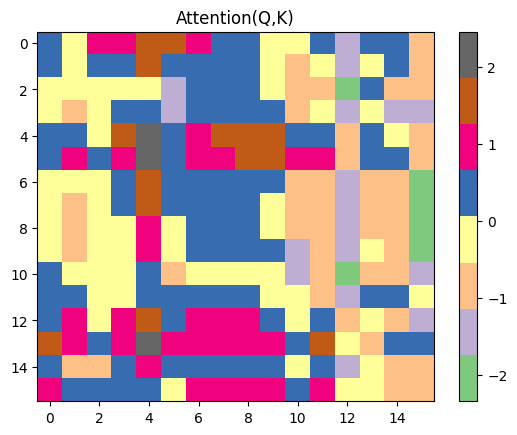

In [27]:
plt.imshow(attn[0, 0].detach().cpu().numpy(), "Accent", aspect="auto")
plt.title("Attention(Q,K)")
plt.colorbar()

In [28]:
# Masking 掩码机制
mask = torch.ones(attn.shape[-2:])
mask = torch.triu(mask, diagonal=1).bool()
attn = attn.masked_fill(mask, float("-inf"))
pd.DataFrame(attn[0][0].detach().cpu().numpy())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.639392,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
1,0.276721,0.016310,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
2,-0.444729,-0.496263,-0.524092,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
3,-0.531785,-0.677133,-0.430977,0.270440,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
4,0.123032,0.119032,-0.420214,1.630439,2.459506,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
5,0.289261,0.678593,0.201966,1.218745,2.130665,0.195394,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
6,-0.288270,-0.438574,-0.176248,0.581388,1.382681,0.107770,0.440549,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
7,-0.301268,-0.558199,-0.165653,0.345363,1.315714,0.199021,0.339456,0.249381,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
8,-0.421261,-0.702673,-0.331817,0.053286,1.197850,0.025042,0.318132,0.230824,0.107255,-inf,-inf,-inf,-inf,-inf,-inf,-inf
9,-0.474480,-0.655254,-0.539797,-0.114924,1.182755,-0.231836,0.444949,0.376317,0.259786,0.126247,-inf,-inf,-inf,-inf,-inf,-inf


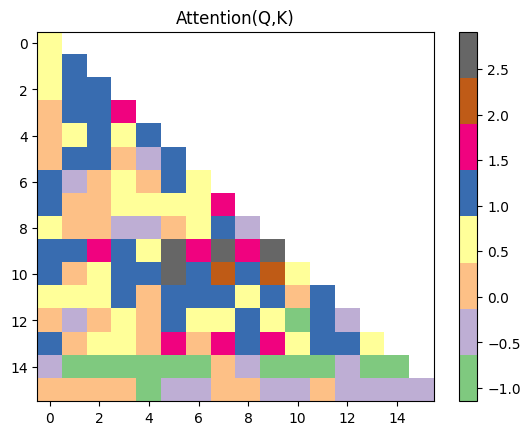

In [29]:
plt.imshow(attn[2, 3].detach().cpu().numpy(), "Accent", aspect="auto")
plt.title("Attention(Q,K)")
plt.colorbar()